### Downsampling
Making an image smaller by reducing the number of pixels.
Example: going from a 1000×1000 photo to 250×250. You’re “throwing away” detail to reduce size.

### Jaggies
Stair-step, blocky edges that appear when smooth lines or curves look rough after downsampling or zooming.
Instead of a smooth diagonal line, you see a “staircase” of pixels.

### Aliasing
The broader problem that causes jaggies and weird patterns.
When you shrink an image too aggressively, fine details interfere with the pixel grid and create false patterns (wavy lines, moiré, flicker in videos). It’s like the image is “lying” about what’s really there because you didn’t sample it finely enough.

### Anti-aliasing
A set of tricks to reduce aliasing before downsampling.
The most common trick: first blur the image a bit (Gaussian smoothing) to remove the finest details, then shrink it. This prevents those false patterns and jaggies from appearing in the smaller image.

### Gaussian smoothing
Blurring the image slightly in a controlled way using a bell-shaped (Gaussian) kernel.
Nearby pixels are averaged, with closer pixels having more influence. This removes very fine detail and sharp transitions.



In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

In [2]:
# create high frequency test image, checkerboard and fine patterns
def create_test_image(size:int = 256):
    # np.linspace creates an array of evenly spaced numbers
    # between the start and end value
    x = np.linspace(0, 8*np.pi, size)
    y = np.linspace(0, 8*np.pi, size)

    # originally x and y are 1 dimensional arrays
    # now X and Y are both 2 dimensional matrices of the same dimensions
    # each value in X represents the X coordinates of a pixel
    # each value in Y reperesnts the Y coordinate of th same pixel.
    X, Y = np.meshgrid(x, y)

    # creates a 2D “wave pattern” image by combining 
    # sine and cosine waves along the x and y directions
    img = np.sin(X) * np.cos(Y)
    #  creates a checkerboard pattern over the 2D grid
    checker = ((X // (np.pi/2)) + (Y // (np.pi/2))) % 2
    # combine checker and image
    img = 0.5 * img + 0.5 * checker
    return img


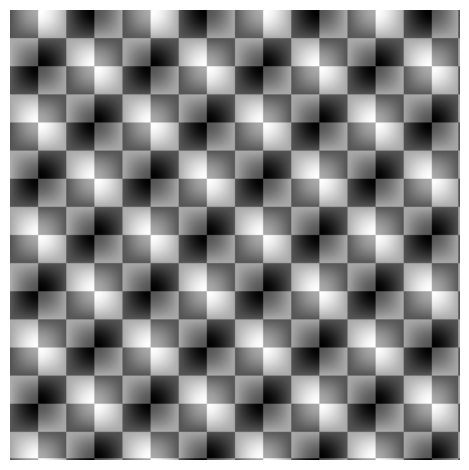

In [3]:
def plot_image(input_image):
    plt.imshow(input_image, cmap='gray')  # 'gray' for grayscale; omit for RGB
    plt.axis('off')               # hide axes
    plt.tight_layout()
    plt.show()
img = create_test_image(256)
plot_image(img)

In [4]:
scale = 4
sigma = scale/2

In [5]:
# apply the gaussian filter before down-sample = anti-aliasing
img_smoothed = gaussian_filter(img, sigma=sigma)

img_smoothed[::scale, ::scale] means:

Take rows 0, scale, 2*scale, 3*scale, ...
And from those rows, take columns 0, scale, 2*scale, 3*scale, ...

In [6]:
img_downsampled_aa = img_smoothed[::scale, ::scale]
img_downsampled = img[::scale, ::scale]

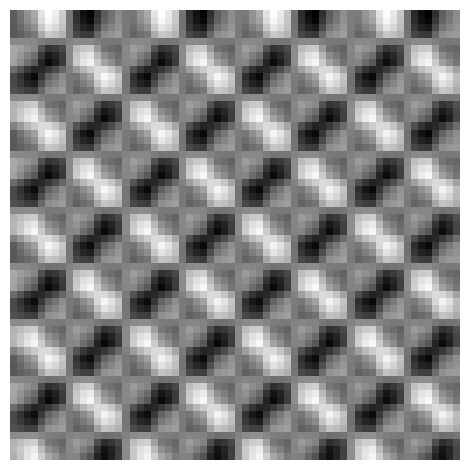

In [7]:
plot_image(img_downsampled_aa)

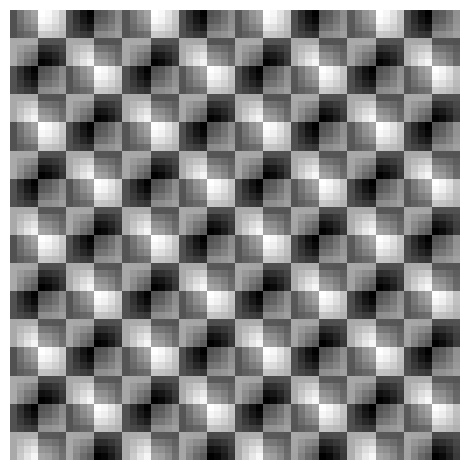

In [8]:
plot_image(img_downsampled)

# Mask-Normalized Filtering: 
Dividing a smoothed image signal by a smoothed validity mask to prevent edge distortion and incorrect weighting near boundary regions.

### The problem: smoothing near invalid regions
Imagine you have a satellite image where some pixels are clouds (no valid surface data)

You represent this with:

* A signal (your actual measurements)
* A mask (1 = valid, 0 = invalid)

When you apply a Gaussian filter directly to the signal:

* The Gaussian kernel averages over a neighborhood. But near invalid regions:
* The kernel spills into invalid areas (where there's no real data)
* Those invalid areas might be filled with 0, NaN, or arbitrary values
* The result: biased, distorted values near edges

In [9]:
# Say you have valid data [10, 20, 30] followed by invalid (masked) region [0, 0, 0]:
signal=np.array([10, 20, 30,  0,  0,  0])
mask=np.array( [True,  True,  True,  False,  False,  False])

In [10]:
# apply the mask and zero out the invalid regions in the signals
signal_masked = np.where(mask, signal, 0.0)
print(signal_masked)

[10. 20. 30.  0.  0.  0.]


In [11]:
# apply gaussian filter to both the signal and the mask
signal_smoothed = gaussian_filter(signal_masked, sigma=3)
mask_smoothed = gaussian_filter(mask.astype(np.float64), sigma=3)

In [12]:
# renormalize by dividing
normalized_signal_smooth = np.zeros_like(signal_smoothed, dtype=np.float64)
np.divide(
    signal_smoothed,
    mask_smoothed,
    out=normalized_signal_smooth,
    where=mask_smoothed > 1e-8  # only divide where mask is non-negligible
)
# apply the mask to zero out the invalid areas
normalized_signal_smooth[~mask] = 0.0
print(normalized_signal_smooth)

[18.9738241  19.23285307 19.74182895  0.          0.          0.        ]


In [13]:
direct_signal_smoothed = gaussian_filter(signal.astype(np.float64), sigma=3)
print(direct_signal_smoothed)

[12.92356578 12.16663731 10.82917062  9.24267445  7.83336269  7.00458915]


# Affine Image Resampling (affine_transform): Using geometric transformation matrices and interpolation 

The Goal: Force a collection of messy, differently-sized, or misaligned images into uniformity so they share the exact same grid dimensions and orientation.

The Tool: Affine transformations driven by geometric matrices and interpolation.

Affine transformations: You can manipulate everything cleanly in 2D space—rotating, scaling, shifting, and shearing (like squishing that coin into an oval)—while strictly respecting the flat plane (no 3D out-of-plane tilting like turning a coin into a line).

e.g.  if you have an image of a US Quarter coin, you can rotate it so that the head appears upside down, you can enlarge it, make it small, squish it within the plane that it appears like an oval etc. You cannot rotate it outside the plane to make it appear as a line or oval

In [14]:
import numpy as np
from scipy.ndimage import affine_transform

Original Image Shape: (6, 6)

Original Image Grid:
 [[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]


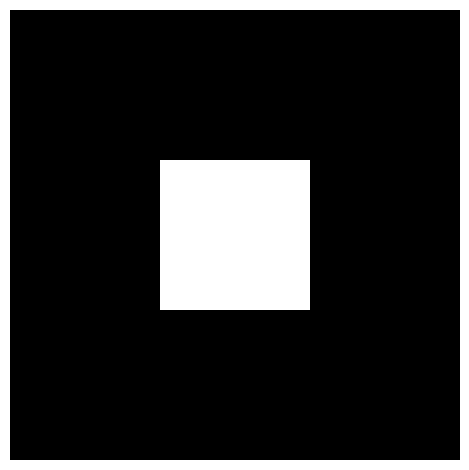

In [18]:
# 1. Create a raw "image" (a 6x6 grid with a simple 2x2 square in the middle)
input_image = np.zeros((6, 6), dtype=float)
input_image[2:4, 2:4] = 1.0

print("Original Image Shape:", input_image.shape)
print("\nOriginal Image Grid:\n", np.round(input_image, 2))
plot_image(input_image)



Standardized Target Grid Shape: (10, 10)

Resulting Standardized Grid:
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


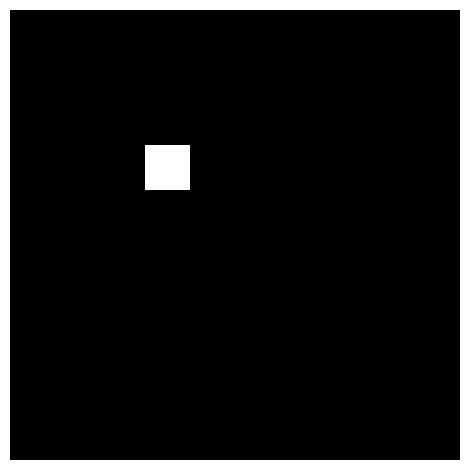

In [20]:
# 2. Define the target standardized grid shape (e.g., a larger 10x10 grid)
target_shape = (10, 10)

# 3. Define the transformation matrix and offset
# A scaling matrix (2.0) shrinks the original content so it fits nicely into the larger grid,
# and an offset centers it.
matrix = np.array([[2.0, 0.0], 
                   [0.0, 2.0]])
offset = np.array([-3.0, -3.0])

# 4. Apply the affine transformation with bilinear interpolation (order=1)
standardized_image = affine_transform(
    input_image, 
    matrix=matrix, 
    offset=offset, 
    output_shape=target_shape, 
    order=1
)

print("Standardized Target Grid Shape:", standardized_image.shape)
print("\nResulting Standardized Grid:\n", np.round(standardized_image, 2))
plot_image(standardized_image)

# Support Mask Thresholding: 

* Binarizing (e.g., > 0.999) the floating-point values in masks supporting  images  
* Goal is to create strict, reliable regions of anatomical validity after resampling.


In [22]:
import numpy as np

# Let's assume we get the below accompanying mask 
# after stretching/resampling an image
fuzzy_mask = np.array([
    [0.0, 0.1, 0.0],
    [0.2, 0.88, 0.9995],
    [0.0, 0.9998, 1.0]
])

# 2. Support Mask Thresholding (drawing the hard line at > 0.999)
# We keep only pixels that are 99.9% certain or higher; everything else becomes 0.
strict_mask = (fuzzy_mask > 0.999).astype(int)

print("Fuzzy Mask :\n", fuzzy_mask)
print("\nStrict Binary Mask (After Thresholding):\n", strict_mask)
# Note: we tr

Fuzzy Mask (After Resampling):
 [[0.     0.1    0.    ]
 [0.2    0.88   0.9995]
 [0.     0.9998 1.    ]]

Strict Binary Mask (After Thresholding):
 [[0 0 0]
 [0 0 1]
 [0 1 1]]
